In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter,lfilter,filtfilt

order = 2
fs = 200
T = 1    
t = np.linspace(0, T, int(fs * T), endpoint=False)

#input signal having three different frquecies -> f = 2, 5, 10
s_t = np.concatenate((5 * np.sin(2 * np.pi * 2 * t)) + (3 * np.sin(2*np.pi*5*t))+2*np.sin(2*np.pi*10*t)
print(s_t.shape)


#cutoff frequecy at which input filter is about to be filtered
f_c = 5  

#Butterworth low pass filter 
b, a = butter(order, [f_c / (fs / 2)], btype='low',analog=False)
#b -> Numerator polynomial coefficients of filter transfer function
#a -> Denominator polynomial coefficients of filter transfer function
#to get a zerophase distortion, this filter is applied. In this operation both
#forward and backward filter is applied
filtered_signal = filtfilt(b,a,s_t)

#As the low pass filter reduces the amplitude of the filtered signal;
#to ensure amplitude remains consistent it should be multiplied with a
#scale factor
scale_factor = 5/max(abs(filtered_signal))
filtered_signal = filtered_signal * scale_factor

print(type(filtered_signal))
print(filtered_signal.shape)

plt.figure(figsize=(12, 6))

# Original signal
plt.subplot(3, 1, 1)
plt.plot(t, s_t, label='Original Signal')
plt.title('Original Signal')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid()
plt.legend()

# Filtered signal
plt.subplot(3, 1, 2)
plt.plot(t, filtered_signal, label='Filtered Signal', color='orange')
plt.title('Filtered Signal (Butterworth lowpass)')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid()
plt.legend()

plt.tight_layout()
plt.show()

In [93]:
import json

triang_data_file = "./datasets/yolo/dataset_v3_yolo26.json"

with open(triang_data_file, 'r') as file:
    triangulation_data = json.load(file)

selected_joints_file = './datasets/yolo/selected_joint_names_v2.json'

with open(selected_joints_file, 'r') as file:
    selected_joints = json.load(file)

list(selected_joints.values())

['lhumerus',
 'rhumerus',
 'lfemur',
 'rfemur',
 'ltibia',
 'rtibia',
 'lfoot',
 'rfoot',
 'lradius',
 'rradius',
 'lwrist',
 'rwrist']

In [94]:
def _butterworth_filter(
        raw_data: np.ndarray, cutoff_frequency: int = 5, order: int = 2, fs: int = 200, scale: bool = False,
    ) -> np.ndarray:
        """
        Butterworth filter applied to movement positions
        """
        # Butterworth low pass filter
        b, a = butter(order, [cutoff_frequency / (fs / 2)], btype="low", analog=False)
        # b -> Numerator polynomial coefficients of filter transfer function
        # a -> Denominator polynomial coefficients of filter transfer function
        # to get a zerophase distortion, this filter is applied. In this operation both
        # forward and backward filter is applied
        filtered_signal = filtfilt(b, a, raw_data)

        if scale:
            # As the low pass filter reduces the amplitude of the filtered signal;
            # to ensure amplitude remains consistent it should be multiplied with a
            # scale factor
            scale_factor = 5 / max(abs(filtered_signal))
            filtered_signal = filtered_signal * scale_factor

        return filtered_signal

In [95]:
def filter_and_show(s_t, cutoff_frequency=5):
    filtered_signal = _butterworth_filter(s_t, cutoff_frequency=cutoff_frequency)
    t = [i for i in range(len(s_t))]
    
    plt.figure(figsize=(12, 6))
    
    # Original signal
    plt.subplot(3, 1, 1)
    plt.plot(t, s_t, label='Original Signal')
    plt.title('Original Signal')
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude')
    plt.grid()
    plt.legend()
    
    # Filtered signal
    plt.subplot(3, 1, 2)
    plt.plot(t, filtered_signal, label='Filtered Signal', color='orange')
    plt.title('Filtered Signal (Butterworth lowpass)')
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude')
    plt.grid()
    plt.legend()
    
    plt.tight_layout()
    plt.show()

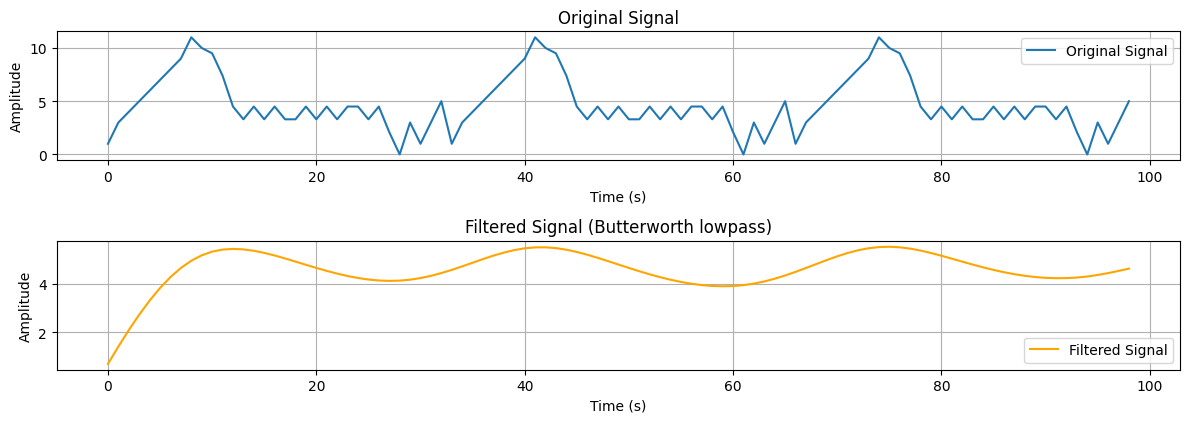

In [96]:
s_t = np.array([1.,3.,4.,5.,6.,7.,8.,9., 11., 10., 9.5,  7.4, 4.5, 3.3, 4.5,3.3, 4.5, 3.3, 3.3, 4.5, 3.3, 4.5, 3.3, 4.5, 4.5, 3.3, 4.5,  2.1 ,0.,3.,1.,3.,5.] * 3)
filter_and_show(s_t)

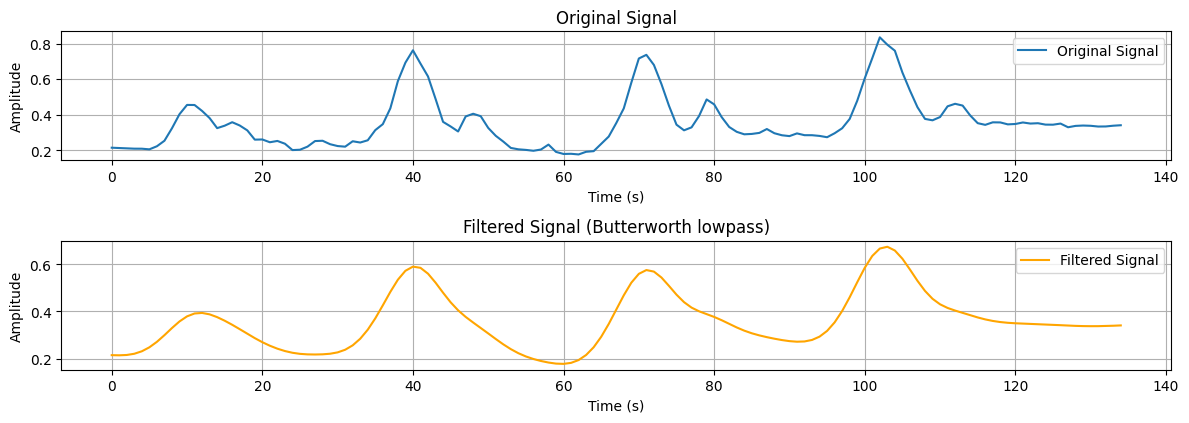

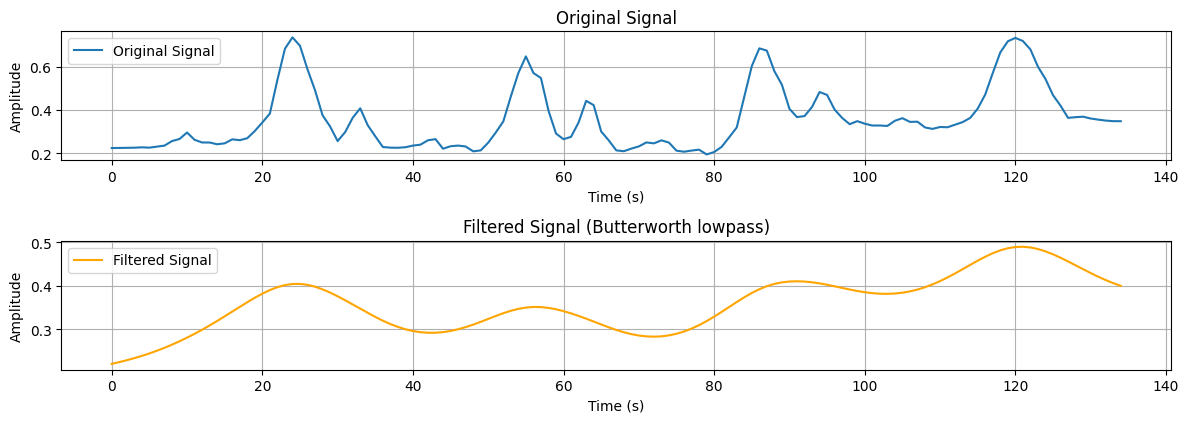

In [97]:
ptcp_key = 'p1s1'
joint = 'lfoot'
i = 2

ptcp_data = triangulation_data[ptcp_key]
s_t = np.array([frame[joint][i] for frame in ptcp_data])
filter_and_show(s_t, cutoff_frequency=14)

joint = 'rfoot'

ptcp_data = triangulation_data[ptcp_key]
s_t = np.array([frame[joint][i] for frame in ptcp_data])
filter_and_show(s_t)

In [86]:
from copy import deepcopy

def _apply_butterworth_filter(ptcp_data):
    new_ptcp_data = deepcopy(ptcp_data)
    
    for joint in ptcp_data[0].keys():
        for i in range(3):
            s_t = np.array([frame[joint][i] for frame in ptcp_data])
            filtered_signal = _butterworth_filter(s_t)
    
            for f_idx, new_value in enumerate(filtered_signal):
                new_ptcp_data[f_idx][joint][i] = new_value

    return new_ptcp_data


In [90]:
ptcp_key = 'p3s1'
ptcp_data = triangulation_data[ptcp_key]

smoothed_ptcp_data = _apply_butterworth_filter(ptcp_data)

In [91]:
ptcp_data[100]

{'lhumerus': [0.6896694900934578, -3.5950404278034744, 5.081411097733586],
 'rhumerus': [-0.4505177002130708, -3.646808855942078, 5.087482170178976],
 'lfemur': [0.5077869761753451, -3.66917061516727, 3.410535791432725],
 'rfemur': [-0.2565455621988712, -3.664915156921661, 3.401704415102795],
 'ltibia': [0.5379825676248268, -4.169116084134657, 1.9788626470733397],
 'rtibia': [-0.08190290983257041, -3.9271493668314137, 1.8842411712231681],
 'lfoot': [0.504521148509969, -3.4909440769248814, 0.7207728741861573],
 'rfoot': [0.08993359672361172, -3.777229208199462, 0.47090074933394993],
 'lradius': [0.9139096156324505, -3.567787859555289, 4.141626906903925],
 'rradius': [-0.6512453153354015, -3.6444464458512518, 4.1373876418161535],
 'lwrist': [1.1142762776455213, -3.9345223019078968, 3.3876139331581223],
 'rwrist': [-0.8325042160045071, -4.0544562933635815, 3.3936900299813715]}

In [92]:
smoothed_ptcp_data[100]

{'lhumerus': [0.7297127087341526, -3.619859936801677, 5.047843445528283],
 'rhumerus': [-0.38852341651063066, -3.6006497239944752, 5.054386202120846],
 'lfemur': [0.5384119157294163, -3.6946603202665274, 3.3710960908515317],
 'rfemur': [-0.20457836071403568, -3.678970319807447, 3.371480669344743],
 'ltibia': [0.4730884756331733, -4.001611325412672, 1.8950203344132046],
 'rtibia': [-0.04142656666591337, -3.945032720308829, 1.8666015537622576],
 'lfoot': [0.38541826397335216, -3.712330529596515, 0.5356352800566971],
 'rfoot': [0.08389769634324198, -3.795513551046529, 0.4907337298238514],
 'lradius': [0.9377084489660215, -3.635777043956293, 4.084564558310952],
 'rradius': [-0.567675666121306, -3.612213872505312, 4.096950131149256],
 'lwrist': [1.1713541245942913, -3.875739610419715, 3.3201282932494043],
 'rwrist': [-0.7215590214598706, -4.005087772069734, 3.3456686271330227]}